<h1>레퍼런스 사이트</h1>

**레퍼런스 사이트 외의 웹사이트나 프로그램 등을 실행할 경우 부정행위로 간주되어 퇴실 조치될 수 있습니다.**<br>
아래 사이트들은 문제 풀이에 반드시 필요한 것은 아니며, 응시자의 편의를 위해 관련 사이트 목록을 모두 제공한 것입니다. 필요에 따라 선택적으로 사용하시기 바랍니다.<br>
<a href="https://docs.python.org/3/reference" target="_blank">python</a> <br>
<a href="https://numpy.org/doc/stable/reference/index.html" target="_blank">numpy</a> <br>
<a href="https://pandas.pydata.org/docs/reference/index.html" target="_blank">pandas</a> <br>
<a href="https://matplotlib.org/stable/api/index.html" target="_blank">matplotlib</a> <br>
<a href="https://pytorch.org/docs/stable/index.html" target="_blank">torch</a> <br>

주관식 실습형 문항은 두 개의 시나리오로 구성됩니다.
이 점 참고하시어 시험 시간을 잘 관리하시기 바랍니다.
- 첫 번째 시나리오 : 실습 1번 ~ 3번 (소문항 7개로 구성)
- 두 번째 시나리오 : 실습 4번 ~ 6번 (소문항 7개로 구성)

# 미래 온도 예측을 통한 예측 공정 최적화

![img](figs/scenario2.jpeg)

정유 및 에너지 산업에서 기온 변화는 화학 반응 속도, 설비 효율, 에너지 소비량 등에 직접적인 영향을 미친다.
특히, 계절별 온도 변화나 급격한 기후 변화는 공정의 안정성을 위협하고, 에너지 소비 최적화를 어렵게 만든다.

이제 당신은 Data Science 팀의 일원으로서, 과거의 기상 데이터와 공정 운영 데이터를 바탕으로 미래의 온도를 예측해야 한다.
이를 통해 최적의 공정 조건을 설정하고, 연료 효율을 극대화하며, 탄소 배출을 줄이는 것이 목표다.

## 시험 주의 사항

- 아래와 같이 **주석으로 구분된 곳에서 코드를 수정 및 작성** 해야하며, 표시된 곳 **이외의 코드 및 하이퍼파라메터 값을 임의로 수정하면 오답 처리 된다.**

```python
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        #
        #                이 곳에서 코드를 수정 및 작성하시오.
        #
        # ================================================================== #
        #          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
        # ================================================================== #
```

- 각 문제마다 **\[답안 검증\] 및 \[답안 제출\]** 셀이 제공된다.
    - **\[답안 검증\]** : 문제에 대한 답안을 중간 점검하기 위한 **최소 조건을 제공**하는 것으로, 실제 정답을 맞췄는지 여부와는 다를 수 있다.
    - **\[답안 제출\]** : 답안 작성 후 **반드시 \[답안 제출\] 셀을 실행**시켜 `skada` 객체로 답을 제출해야 정답으로 인정된다. **답안제출 코드를 임의로 수정하면 정상 제출을 보장하지 않는다**.
- 모든 문제의 답안 제출 코드 실행을 완료하고, 마지막으로 **런박스 상단의 제출버튼**을 눌러야 답안이 최종 제출된다.

이하의 과제를 풀기 위하여 아래와 같은 라이브러리를 활용해 볼 수 있다.

In [1]:
import os
import pickle
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import utils
skada = utils.SKADA.instance()

필요하다면 [파이썬 표준 라이브러리](https://docs.python.org/3/library/index.html) 내 모듈이나 설치된 라이브러리를 임의로 불러올 수 있다.

In [2]:
import itertools, functools, collections # 기타 필요한 모듈 ...

# 목차

**IV. 데이터 전처리 및 시각화** (문제 4)
    
**V. 베이스라인 모델 구현** (문제 5-1, 5-2)
    
**VI. 모델 고도화** (문제 6-1, 6-2, 6-3, 6-4)

# IV. 데이터 준비
## [문제 4]
### [데이터 설명 4]

현장 담당자로부터 전달 받은 시간별 센서 데이터의 상세 정보는 다음과 같다. 이전 문제와 마찬가지로 학습용 데이터와 테스트용 데이터는 2개의 열로 구성되어있고, 첫번째 열은 시간, 그리고 두 번째 열은 기온을 나타낸다.

* 데이터셋 구조 : 테이블 형식(Tabular)로, 총 2개의 칼럼과 30000(train)개의 학습용 샘플, 그리고 22696(test)개의 테스트용 샘플로 구성되어 있다.
* 수집 기간 (학습 데이터) : 2020-01-01 00:10:00 ~ 2020-07-27 09:20:00
* 수집 기간 (테스트 데이터) : 2020-07-27 09:30:00 ~ 2021-01-01 00:00:00
* 수집 단위 : 10분
* Feature 설명 : `date` (시간, datetime), `T` (기온; Degree Celcius)

In [3]:
df_train = pd.read_csv('./data/temperature_train.csv')
df_test = pd.read_csv('./data/temperature_test.csv')
print(df_train.shape)
print(df_test.shape)
print(df_train.head())
print(df_train.tail())
print(df_test.head())
print(df_test.tail())

(30000, 2)
(22696, 2)
                  date  T (degC)
0  2020-01-01 00:10:00      0.71
1  2020-01-01 00:20:00      0.75
2  2020-01-01 00:30:00      0.73
3  2020-01-01 00:40:00      0.37
4  2020-01-01 00:50:00      0.33
                      date  T (degC)
29995  2020-07-27 08:40:00     19.99
29996  2020-07-27 08:50:00     20.55
29997  2020-07-27 09:00:00     20.57
29998  2020-07-27 09:10:00     21.27
29999  2020-07-27 09:20:00     22.04
                  date  T (degC)
0  2020-07-27 09:30:00     22.33
1  2020-07-27 09:40:00     22.49
2  2020-07-27 09:50:00     23.23
3  2020-07-27 10:00:00     23.51
4  2020-07-27 10:10:00     24.08
                      date  T (degC)
22691  2020-12-31 23:20:00      2.28
22692  2020-12-31 23:30:00      2.13
22693  2020-12-31 23:40:00      1.99
22694  2020-12-31 23:50:00      2.07
22695  2021-01-01 00:00:00      2.01


### [상황 설명 4]

우리는 Time Series가 주어졌을 때 앞으로 일어날 일을 예측하는 time series forecasting 모델을 학습하고자 한다. 이 때, 우리는 특정 patch (window) 단위로 다음 스텝을 예측하는 모델을 학습하고자 한다. 이를 위해서 ```window_size``` 만큼의 길이를 가지는 시계열이 input으로, 그리고 이로부터 ```horizon```만큼 lagging 된 시계열이 label으로 주어지는 데이터셋을 만들어보자.

![fig](figs/forecast_dataset.png)


### [문제 설명 4] Patch 단위의 시계열 예측을 위한 데이터셋 준비 (4점)

Dataloader 구현에 사용할 함수 ```create_multi_step_sequences```를 완성해보자.

- 조건 1: ```create_multi_step_sequences``` 함수는 dataframe을 받아 매 index마다 ```window_size```만큼의 길이를 가지는 시계열을 ```X``` 리스트에 append하고, 그로부터 ```horizon```만큼 lagging된 값을 ```y``` 리스트에 append한다.
- 조건 2: ```X```나 ```y```에 append 되는 시계열은 전체 데이터의 길이를 넘지 않는다.
- 조건 3: ```X``` 에 append되는 시계열의 shape은 ```(window_size, 1)```, ```y```에 append되는 시계열의 shape은 ```(horizon, 1)```이다.
- 조건 4: ```train```이라는 keyword argument를 받아 ```True```라면 overlapping하는 window 전부를 ```X```와 ```y```에 append하고, ```False```라면 ```horizon```만큼의 striding을 진행하며 ```X```와 ```y```에 append한다.

In [14]:
def create_multi_step_sequences(df, window_size, horizon, train=True):
    X, y = [], []
    # ================================================================== #
    #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
    # ================================================================== #

    data = np.array(df["T (degC)"], dtype=float)
    
    stride = 1 if train else horizon
    
    for i in range(0, len(data) - window_size - horizon + 1, stride):
        X.append(data[i:i+window_size, None])
        y.append(data[i+window_size:i+window_size+horizon, None])
    
    # ================================================================== #
    #          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
    # ================================================================== #
    return np.array(X), np.array(y)

### [답안 검증 4]

제대로 구현을 했다면, 중간에 있는 assert 문에서 오류가 발생하지 않는다.

In [15]:
window_size = 784
horizon = 196

X_train_np, y_train_np = create_multi_step_sequences(df_train, window_size, horizon, train=True)
X_test_np, y_test_np   = create_multi_step_sequences(df_test, window_size, horizon, train=False)


batch_size = 32

# Convert numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)  # shape: [N_train, 784, 1]
y_train = torch.tensor(y_train_np, dtype=torch.float32)  # shape: [N_train, 196, 1]
X_test  = torch.tensor(X_test_np, dtype=torch.float32)   # shape: [N_test, 784, 1]
y_test  = torch.tensor(y_test_np, dtype=torch.float32)   # shape: [N_test, 196, 1]

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

assert len(train_dataset) == 29021
assert len(test_dataset) == 111

x, y = next(iter(train_loader))

assert x.shape == (32, 784, 1)
assert y.shape == (32, 196, 1)

### [답안 제출 4] 수정 금지, 실행만 하시오.

In [16]:
skada.Q4_1_answer(create_multi_step_sequences)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


# V. 모델 아키텍쳐 구현

## [문제 5-1]

### [문제 설명 5-1 (주관식 서술형)] 시계열 patch 단위 처리의 이점 (6점)

**Q.** 시계열을 다룰 때, 처리의 단위를 다르게 할 수 있다. 포인트 하나씩 처리를 하는 방법이 있고, 여러 개의 포인트를 병합하여 **patch** 를 신호의 단위로 처리를 할 수 있다.
이렇게 보면, 포인트를 하나씩 처리하는 경우는 patch의 길이를 1로 설정하는 특수 케이스로 볼 수 있다.
patch의 길이를 늘려서 이용할 때, 그 장점과 단점이 무엇인가? (하나씩 적으면 정답으로 처리한다.)

👉 아래에 서술형으로 작성하세요 (최대 100자). 마크다운 블록에 답안을 적고, 해당 답안을 string으로 저장하여 ```answer_str```로 제출해주세요.

### 답안 작성 칸

**A.**

- 장점: 
- 단점: 

In [ ]:
answer_str = " "

skada.Q5_1_answer(answer_str)

## [문제 5-2]

### [상황 설명 5-2]

본 문제에서는 patch를 이용하는 대표적인 모델인 PatchTST 를 이용해보자.

### [이론 설명 5-2 (Optional)]

![PatchTST](./figs/PatchTST_model_architectrue.JPG)

아래의 의미를 가지는 variable이 있다고 하자.
- ```L```: sequence length
- ```N```: token 갯수
- ```P```: patch 길이
- ```C```: feature의 갯수. 우리의 경우 늘 1이다.
- ```D```: transformer의 hidden dimension
- ```T```: 예측하고자 하는 미래 time series의 길이 (horizon)

1. **Patching**: ```L```길이의 time series가 들어온다면, 이는 ```P```만큼의 길이를 가지는 patch로 쪼개져, 총 ```N = L//P```만큼의 token이 된다. 예컨대 주어진 시계열의 길이가 ```L=784```이고, patch의 길이가 ```P=16```으로 주어졌다면, 총 ```N = 784/16 = 49``` 개의 token으로 변환되는 것이다. 이러한 patching 과정은 $x^{(i)} \in \mathbb{R}^{1 \times L}$를 $x_p^{(i)} \in \mathbb{R}^{P \times N}$으로 변환한다.

2. **Projection + Position Embedding** (아래 ```PPEmbedding``` 클래스 참조): 주어진 patch $x_p^{(i)} \in \mathbb{R}^{P \times N}$를 Transformer dimension으로 projection 시키고, 각 token에 같은 dimension의 learnable positional embedding을 더해주는 과정이고, 이 과정을 통과하여 $x_d^{(i)} \in \mathbb{R}^{D \times N}$ feature가 나온다. 이는 Transformer Encoder의 input이 된다.

3. **Transformer Encoder**: Transformer encoder 구조를 통과하여, input $x_d^{(i)} \in \mathbb{R}^{D \times N}$ 이 output $z^{(i)} \in \mathbb{R}^{D \times N}$ 로 변환된다.

4. **Flatten + Linear Head**: 주어진 output feature인 $z^{(i)} \in \mathbb{R}^{D \times N}$를 flatten하여 $1\times DN$ 디멘션으로 만들고, 이를 ```nn.Linear``` layer를 통과하여 $\hat{x}^{(i)} \in \mathbb{R}^{1 \times T}$ 모양의 최종 ouptut을 만든다.

In [17]:
class PPEmbedding(nn.Module):
    def __init__(self, num_token: int, num_features: int, d_model: int):
        """
        Positional and patch embedding.
        Args:
            num_token: number of patches (tokens)
            num_features: size of each patch (number of time steps per patch)
            d_model: embedding dimension
        """
        super(PPEmbedding, self).__init__()
        self.dropout = nn.Dropout(p=0.1)
        self.W_proj = nn.Linear(num_features, d_model)
        self.W_pos = nn.Parameter(torch.ones(num_token, d_model), requires_grad=True)

    def forward(self, x_inp: torch.Tensor) -> torch.Tensor:
        # x_inp shape: [batch, num_token, num_features]
        x_inp = self.W_proj(x_inp)
        x_pos = self.dropout(x_inp + self.W_pos)
        return x_pos

In [18]:
class PatchTST(nn.Module):
    def __init__(self, sequence_length: int, horizon: int, num_token: int, num_features: int,
                 d_model: int, nhead: int = 8, dim_feedforward: int = 256, dropout: float = 0.1, num_layers: int = 2,):
        """
        PatchTST model configured for multi-step prediction.
        Args:
            sequence_length: length of the input time series window (e.g., 784)
            horizon: number of future time steps to predict (e.g., 196)
            num_token: number of patches to split the sequence into; must divide sequence_length evenly
            num_features: number of input features (channels) per time step
            d_model: embedding dimension
            nhead: number of attention heads in the Transformer encoder layer
            dim_feedforward: dimension of the feedforward network in the Transformer encoder
            dropout: dropout rate
            num_layers: number of Transformer encoder layers
            predict_sigma: if True, also predict the sigma
        """
        super(PatchTST, self).__init__()
        assert sequence_length % num_token == 0, "sequence_length must be divisible by num_token"
        self.patch_length = sequence_length // num_token
        self.horizon = horizon

        # PPEmbedding takes patches of length patch_length for each token
        self.ppe_layer = PPEmbedding(num_token, self.patch_length, d_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers)
        self.linear = nn.Linear(num_token * d_model, horizon)
        # Forecasting head outputs a patch of predictions (horizon time steps) for each channel
        self.head = nn.Sequential(
            nn.Flatten(start_dim=-2),  # flatten across tokens and embedding dimension
            self.linear,
        )

    def patching(self, z: torch.Tensor) -> torch.Tensor:
        """
        Splits the input sequence into non-overlapping patches.
        Args:
            z: tensor of shape [batch, sequence_length, 1]
        Returns:
            tensor of shape [batch, num_token, patch_length]
        """
        z = z.squeeze(2).unfold(dimension=1, size=self.patch_length, step=self.patch_length)
        return z

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass that outputs a multi-step forecast for each channel.
        Args:
            x: input tensor of shape [batch, sequence_length, num_features]
        Returns:
            forecast tensor of shape [batch, horizon, num_features]
        """
        B, L, C = x.shape
        z = x.permute(0, 2, 1)          # shape: [B, num_features, sequence_length]
        z = z.reshape(B * C, L, 1)      # shape: [B*num_features, sequence_length, 1]
        z = self.patching(z)            # shape: [B*num_features, num_token, patch_length]
        z = self.ppe_layer(z)           # shape: [B*num_features, num_token, d_model]
        z = self.encoder(z)             # shape: [B*num_features, num_token, d_model]
        z = self.head(z)                # shape: [B*num_features, horizon]
        z = z.reshape(B, C, self.horizon)  # shape: [B, num_features, horizon]
        mean = z.permute(0, 2, 1)
        return mean

In [19]:
sequence_length = 784
horizon = 196
num_token = 49
num_features = 1
d_model = 64

device = 'cuda:0'

model = PatchTST(sequence_length=sequence_length, horizon=horizon, num_token=num_token,
                num_features=num_features, d_model=d_model).to(device)

# model patching
x_ = torch.randn([100, sequence_length, 1])
y_ = model.patching(x_)
assert y_.shape == (100, num_token, model.patch_length)


# model forward
x = torch.randn([1, sequence_length, num_features]).to(device)
y = model(x)
assert y.shape == (1, horizon, num_features)

준비된 모델을 이용해 모델 학습을 진행한다.

In [20]:
# ---------------------------
# Hyperparameters and Model Instantiation
# ---------------------------
sequence_length = 784
horizon = 196
num_token = 49             # Ensure that sequence_length is divisible by num_token (784/49 = 16)
num_features = 1
d_model = 64
nhead = 8
dim_feedforward = 256
num_layers = 2
learning_rate = 1e-3
num_epochs = 10

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# ---------------------------
# Training Loop
# ---------------------------
total_training_loop = 1000

model.train()
for idx, (x_batch, y_batch) in enumerate(train_loader):
    optimizer.zero_grad()
    # x_batch: [batch, sequence_length, num_features]
    # y_batch: [batch, horizon, num_features]
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    output = model(x_batch)
    loss = criterion(output, y_batch)
    loss.backward()
    optimizer.step()
    if idx % 50 == 0:
        print(f"Iter {idx+1}/{total_training_loop}, Train Loss: {loss:.6f}")
    if idx >= total_training_loop:
        break

Iter 1/1000, Train Loss: 144.672302
Iter 51/1000, Train Loss: 22.665197
Iter 101/1000, Train Loss: 10.053717
Iter 151/1000, Train Loss: 10.603694
Iter 201/1000, Train Loss: 10.362095
Iter 251/1000, Train Loss: 11.641492
Iter 301/1000, Train Loss: 12.594944
Iter 351/1000, Train Loss: 9.832075
Iter 401/1000, Train Loss: 11.473109
Iter 451/1000, Train Loss: 10.143999
Iter 501/1000, Train Loss: 7.325325
Iter 551/1000, Train Loss: 10.109081
Iter 601/1000, Train Loss: 8.784660
Iter 651/1000, Train Loss: 10.524719
Iter 701/1000, Train Loss: 10.235797
Iter 751/1000, Train Loss: 8.307581
Iter 801/1000, Train Loss: 6.791576
Iter 851/1000, Train Loss: 9.060385
Iter 901/1000, Train Loss: 6.854335


이전 학습에 문제가 있었다면, 다음 코드를 통해 미리 학습된 모델 파라미터를 로드하여 이후 문제를 해결할 수 있다.

In [21]:
def load_model(model, path="./models/forecast_weight.pt", device='cuda'):
    if not os.path.exists(path):
        raise FileNotFoundError(f"No model weights found at {path}")

    model.load_state_dict(torch.load(path, map_location=device))
    print(f"Model weights loaded from {path}")
    return model

model = load_model(model, path="./models/forecast_weight.pt")

Model weights loaded from ./models/forecast_weight.pt


지금까지 준비된 모델과 데이터셋을 통해 모델을 학습했다. 

학습된 모델 웨이트를 이용해 테스트셋에서 시계열 예측을 진행한다. 테스트 데이터의 첫 input을 받아 시계열 예측을 진행하고, 그 결과를 ground truth와 overlay하여 비교해보자.

### [이론 설명 (Optional)]

현재 우리에게는 ```window_size```길이만큼의 sequence가 주어졌을 때 ```horizon```길이만큼의 시계열을 예측할 수 있는 모델이 있다. 이 때 크게 두 가지 방식으로 모델을 평가 할 수 있다. 이를 반복적으로 사용하면 미래에 대한 시계열을 예측하는 것이 가능해진다. 이 때, 모델의 성능을 평가하는 데에는 크게 두가지 방법이 있다. 그 중 첫번째는 teacher forcing 방법을 이용하는 것으로, 반복적으로 model을 query할 때, 이전 prediction은 무시하고, 정답 sequence로 대체하여 반복적인 예측을 수행하는 과정이다.

예시를 들자면 다음과 같다. ```[:window_size]``` 길이의 시계열이 주어진다고 할 때, ```[window_size:window_size+horizon]``` 만큼의 시계열을 예측한다. 이 다음 단계에서는 이 예측된 값을 무시하고, 정답 sequcne의 ```[horizon:window_size+horizon]```을 이용하여 ```[window_size+horizon:window_size+2*horizon]```을 예측하는 식이다.

이를 **Teacher forcing** 이라고 하고, 아래와 같이 구현할 수 있다.

In [27]:
y_test[0:1].shape

torch.Size([1, 196, 1])

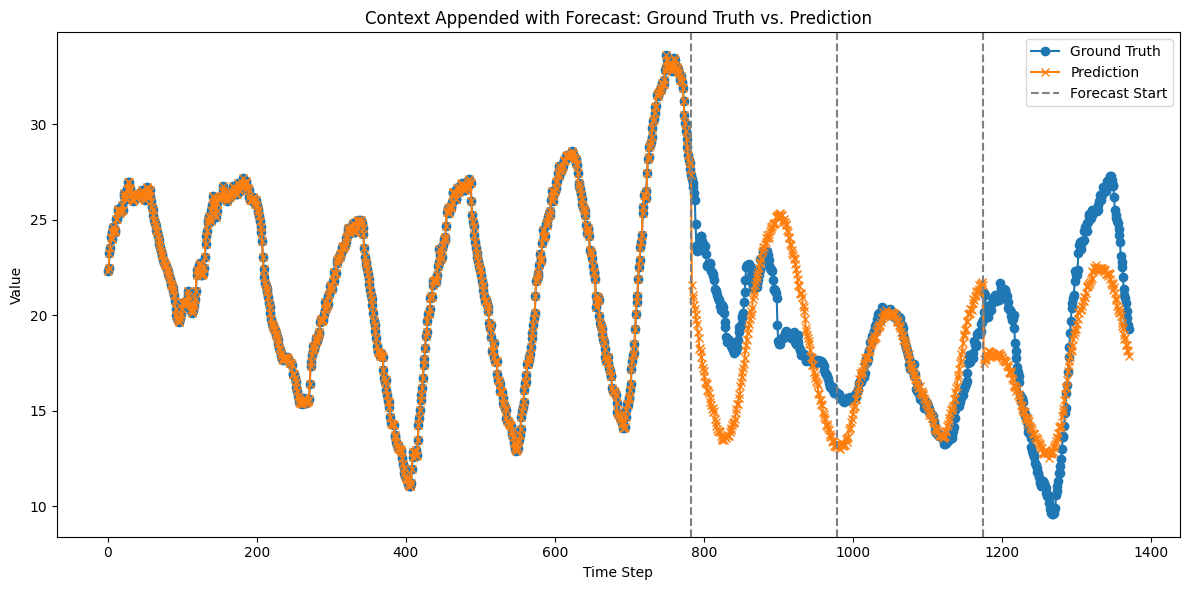

In [28]:
model.eval()
sample_idx = 0

for sample_idx in range(3):
    with torch.no_grad():
        x_context = X_test[sample_idx:sample_idx+1]
        x_context = x_context.to(device)
        y_true_future = y_test[sample_idx:sample_idx+1]

        # Get the predicted future patch (direct multi-step prediction)
        y_pred_future = model(x_context)  # shape: [1, horizon, num_features]

        if sample_idx == 0:
            full_ground_truth = np.concatenate([x_context.squeeze().cpu().numpy(), y_true_future.squeeze().cpu().numpy()])
            full_prediction = np.concatenate([x_context.squeeze().cpu().numpy(), y_pred_future.squeeze().cpu().numpy()])
        else:
            full_ground_truth = np.concatenate([full_ground_truth, y_true_future.squeeze().cpu().numpy()])
            full_prediction = np.concatenate([full_prediction, y_pred_future.squeeze().cpu().numpy()])

# Plot the results
full_time = np.arange(len(full_ground_truth))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(full_time, full_ground_truth, label='Ground Truth', marker='o')
ax.plot(full_time, full_prediction, label='Prediction', marker='x')

ax.axvline(window_size - 1, color='gray', linestyle='--', label='Forecast Start')
ax.axvline(window_size + horizon - 1, color='gray', linestyle='--')
ax.axvline(window_size + 2 * horizon - 1, color='gray', linestyle='--')

ax.set_xlabel('Time Step')
ax.set_ylabel('Value')
ax.set_title('Context Appended with Forecast: Ground Truth vs. Prediction')
ax.legend()

plt.tight_layout()

### [이론 설명 5-2]

두 번째 방법은 model forcing이다. 반복적으로 model을 query할 때, 이전 prediction을 활용하여 반복적인 예측을 수행하는 과정이다.

예시를 들자면 다음과 같다. ```[:window_size]``` 길이의 시계열이 주어진다고 할 때, ```[window_size:window_size+horizon]``` 만큼의 시계열을 예측한다. 이 다음 단계에서는 이 예측된 값을 포함하여 갖고 있는 부분 중 ```[horizon:window_size+horizon]```만큼을 이용하여 ```[window_size+horizon:window_size+2*horizon]```을 예측하는 식이다.


### [문제 설명 5-2] Model Forcing을 이용한 multi-horizon forecasting (6점)

아래 조건에 따라 Model forcing을 이용한 multi-horizon forecasting을 완성해보자.

- 조건 1: for loop을 3번 돌며 나오는 ```x_context```를 그대로 이용하는 것이 아닌, 모델이 이전 스텝에서 예측한 부분만큼은 예측값으로 대체하여 반복적인 시계열 예측을 수행한다.
- 조건 2: 첫 prediction의 경우 ```y_true_future```와 ```y_pred_future``` 는 각각 ```x_context``` 뒤에 append해서 ```full_ground_truth```와 ```full_prediction```을 만든다.
- 조건 3: 차후 prediction의 경우 ```y_true_future``` 와 ```y_pred_future``` 를 각각 ```full_ground_truth``` 와 ```full_prediction``` 에 iterative하게 append한다.

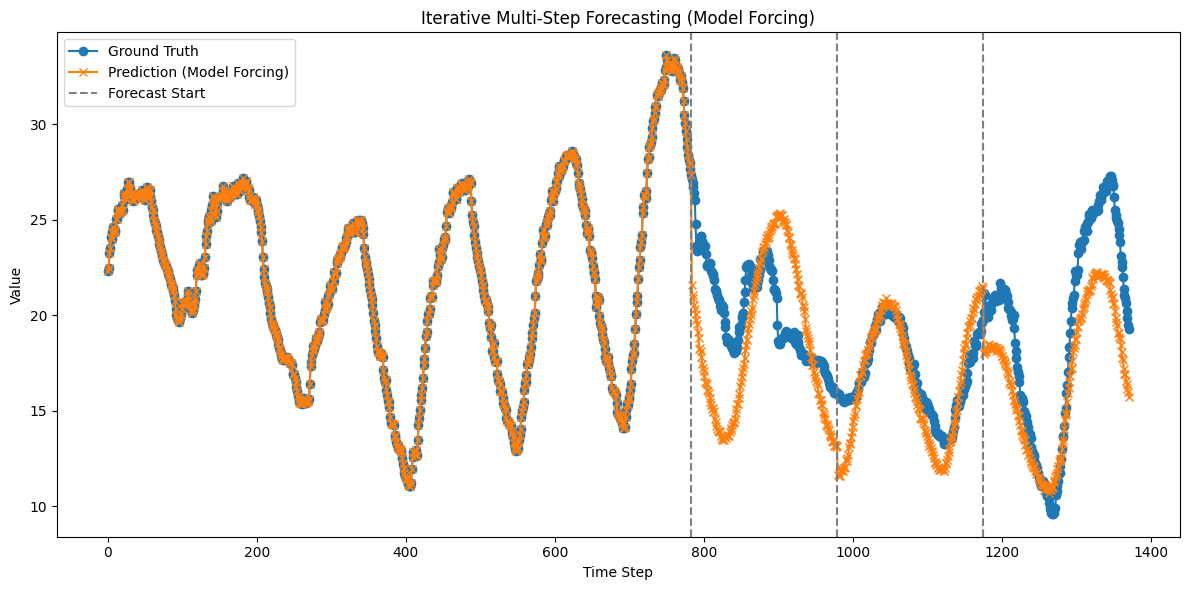

In [38]:
model.eval()
sample_idx = 0

with torch.no_grad():
    # Initialize input sequence
    x_context = X_test[sample_idx:sample_idx+1]  # [1, window_size, num_features]
    x_context_np = x_context.squeeze().cpu().numpy()  # Convert to NumPy
    window_size = x_context_np.shape[0]
    horizon = y_test.shape[1]  # Horizon size

    full_ground_truth = x_context_np.copy()
    full_prediction = x_context_np.copy()

    # Iteratively forecast over multiple steps (model forcing)
    for i in range(3):  # Perform 3 iterative forecasts

        # ================================================================== #
        #           START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)      #
        # ================================================================== #

        x_context = x_context.to(device).float()
        y_pred_future = model(x_context)  # B, S, C
        y_pred_future = y_pred_future.squeeze().cpu().numpy()
        full_prediction = np.concatenate([full_prediction, y_pred_future])
        full_ground_truth = np.concatenate([full_ground_truth, y_test[sample_idx+i].squeeze().cpu().numpy()])
        
        x_context = torch.tensor(full_prediction[-window_size:], device=device, dtype=float)
        x_context = x_context[None, :, None]
        
        # ================================================================== #
        #           END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #

# Time axis
total_length = full_prediction.shape[0]
full_time = np.arange(total_length)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(full_time, full_ground_truth, label='Ground Truth', marker='o')
ax.plot(full_time, full_prediction, label='Prediction (Model Forcing)', marker='x', linestyle='-')

ax.axvline(window_size - 1, color='gray', linestyle='--', label='Forecast Start')
ax.axvline(window_size + horizon - 1, color='gray', linestyle='--')
ax.axvline(window_size + 2 * horizon - 1, color='gray', linestyle='--')

ax.set_xlabel('Time Step')
ax.set_ylabel('Value')
ax.set_title('Iterative Multi-Step Forecasting (Model Forcing)')
ax.legend()

plt.tight_layout()

### [답안 검증 5-2]

위 문제를 제대로 해결했다면, 다음과 비슷한 plot을 얻을 수 있다.

![plot](./figs/sample_fig_5_3.png)

### [답안 제출 5-2] 수정 금지, 실행만 하시오.

In [39]:
skada.Q5_2_answer(fig)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


# VI. 모델 고도화

## [문제 6-1]
 
### [이론 및 상황 설명 6-1 (Optional)]

MSE loss를 사용해 시계열 예측 모델을 학습한다는 것은 output probability를 고정된 분산의 Gaussian으로 모델링한다는 의미한다. $D$ 차원의 데이터에 대한 Gaussian Likelihood를 풀어쓰자면 아래와 같다.

$$
p(\mathbf{x_i}|\mathbf{\mu}) = \frac{1}{(2\pi\sigma^2)^{D/2}} \exp \left(-\frac{1}{2\sigma^2} \|\mathbf{x_i} - \mathbf{\mu}\|_2^2\right)
$$

위 경우 전체 데이터셋 $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ log-likelihood는 아래와 같다.

$$
\mathcal{L} = \sum_{i=1}^N \log p(\mathbf{x}_i|\mathbf{\mu}) = -\frac{ND}{2} \log (2\pi) - \frac{ND}{2}\log (\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^N \|\mathbf{x}_i - \mathbf{\hat\mu_i}\|_2^2
$$

학습 과정은 negative log likelihood를 minimize하는 과정이다. $\mathcal{L}$은 $\mathbf{\mu}$ 에 대하여 상수이므로, 우리가 기존에 사용한 loss function이 나오게 되는 것을 확인 할 수 있다.

$$
\mathcal{L}_{MSE} = \frac{1}{2\sigma^2}\sum_{i=1}^N \|\mathbf{x}_i - \mathbf{\hat\mu_i}\|_2^2
$$

이 때 $\hat{u}_i$ 의 예측을 위해 네트워크의 예측값인 $\mathbf{\mu}_\theta(\mathbf{x}_i)$ 를 이용하였다.

반면에 이제 네트워크가 분산까지 모델링한다고 하자. 그렇다면 이제 분산이 더 이상 상수가 아니므로, 아래와 같이 loss를 쓸 수 있다.

$$
\mathcal{L}_{MLE} = \frac{1}{N}\sum_{i=1}^N\left(\frac{\|\mathbf{x}_i - \hat\mu_i\|_2^2}{2\hat\sigma^2} + \frac{D}{2}\log\hat\sigma^2\right)
$$

따라서 전반적으로 같은 모델 구조를 쓰더라도, 평균과 분산을 함께 모델링하여 위 Gaussian log likelihood loss로 학습을 하면, **모델의 uncertainty까지 같이 예측이 가능하다.**

### [문제 설명 6-1] 평균 분산 예측 모델 구현 (6점)

아래 조건에 따라 기존에 구현한 ```PatchTST``` 모델의 구조를 변형해보자.

- 조건 1: ```self.linear``` 함수는 마지막 단계의 linear head로, 기존에는 ```horizon``` 디멘션만큼의 텐서로 평균값을 예측하였다. ```predict_sigma```가 ```False```라면 기존 형태를 유지하고, ```True```라면 ```2 * horizon```디멘션만큼의 텐서를 output하는 linear head를 정의해보자.
- 조건 2: ```forward```함수에서도 ```predict_sigma```에 따라 ```False```라면 기존 구조를 유지하도록, ```True```라면 ```mean```과 ```std```를 예측하도록 한다.
- 조건 3: linear head output의 ```[:self.horizon]```까지는 mean을, ```[self.horizon:]``` 부터는 std를 예측하도록 한다.

**[주의]** ```self.linear```는 ```self.head```에서 이용된다.

In [42]:
class PatchTST(nn.Module):
    def __init__(self, sequence_length: int, horizon: int, num_token: int, num_features: int,
                 d_model: int, nhead: int = 8, dim_feedforward: int = 256, dropout: float = 0.1, num_layers: int = 2,
                 predict_sigma: bool = False):
        """
        PatchTST model configured for multi-step prediction.
        Args:
            sequence_length: length of the input time series window (e.g., 784)
            horizon: number of future time steps to predict (e.g., 196)
            num_token: number of patches to split the sequence into; must divide sequence_length evenly
            num_features: number of input features (channels) per time step
            d_model: embedding dimension
            nhead: number of attention heads in the Transformer encoder layer
            dim_feedforward: dimension of the feedforward network in the Transformer encoder
            dropout: dropout rate
            num_layers: number of Transformer encoder layers
            predict_sigma: if True, also predict the sigma
        """
        super(PatchTST, self).__init__()
        assert sequence_length % num_token == 0, "sequence_length must be divisible by num_token"
        self.patch_length = sequence_length // num_token
        self.horizon = horizon
        self.predict_sigma = predict_sigma

        # PPEmbedding takes patches of length patch_length for each token
        self.ppe_layer = PPEmbedding(num_token, self.patch_length, d_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers)
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        
        if predict_sigma:
            self.linear = nn.Linear(num_token * d_model, self.horizon * 2)
        else:
            self.linear = nn.Linear(num_token * d_model, self.horizon)
        
        # ================================================================== #
        #         END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)          #
        # ================================================================== #
        # Forecasting head outputs a patch of predictions (horizon time steps) for each channel
        self.head = nn.Sequential(
            nn.Flatten(start_dim=-2),  # flatten across tokens and embedding dimension
            self.linear,
        )

    def patching(self, z: torch.Tensor) -> torch.Tensor:
        """
        Splits the input sequence into non-overlapping patches.
        Args:
            z: tensor of shape [batch, sequence_length, 1]
        Returns:
            tensor of shape [batch, num_token, patch_length]
        """
        z = z.squeeze(2).unfold(dimension=1, size=self.patch_length, step=self.patch_length)
        return z

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass that outputs a multi-step forecast for each channel.
        Args:
            x: input tensor of shape [batch, sequence_length, num_features]
        Returns:
            forecast tensor of shape [batch, horizon, num_features]
        """
        B, L, C = x.shape
        # Start with the forward of PatchTST
        z = x.permute(0, 2, 1)          # shape: [B, num_features, sequence_length]
        z = z.reshape(B * C, L, 1)      # shape: [B*num_features, sequence_length, 1]
        z = self.patching(z)            # shape: [B*num_features, num_token, patch_length]
        z = self.ppe_layer(z)           # shape: [B*num_features, num_token, d_model]
        z = self.encoder(z)             # shape: [B*num_features, num_token, d_model]
        z = self.head(z)                # shape: [B*num_features, horizon]
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        
        if self.predict_sigma:
            z = z.reshape(B, C, self.horizon * 2)
            mean_std = z.permute(0, 2, 1)
            mean = mean_std[:, :self.horizon]
            std = mean_std[:, self.horizon:]
            return mean, std
        
        z = z.reshape(B, C, self.horizon)
        mean = z.permute(0, 2, 1)
        
        # ================================================================== #
        #         END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)          #
        # ================================================================== #
        return mean

### [답안 검증 6-1]

제대로 구현을 했다면, 아래에서 오류가 발생하지 않는다.

In [43]:
model = PatchTST(sequence_length=sequence_length, horizon=horizon, num_token=num_token,
                 num_features=num_features, d_model=d_model, nhead=nhead,
                 dim_feedforward=dim_feedforward, num_layers=num_layers,
                 predict_sigma=True)

x = torch.randn([1, 784, 1])
mean, std = model(x)
assert mean.shape == (1, horizon, num_features)
assert std.shape == (1, horizon, num_features)

# predicg_sigma = False
model = PatchTST(sequence_length=sequence_length, horizon=horizon, num_token=num_token,
                 num_features=num_features, d_model=d_model, nhead=nhead,
                 dim_feedforward=dim_feedforward, num_layers=num_layers,
                 predict_sigma=False)

x = torch.randn([1, 784, 1])
mean = model(x)
assert mean.shape == (1, horizon, num_features)

### [답안 제출 6-1] 수정 금지, 실행만 하시오.

In [44]:
skada.Q6_1_answer((PatchTST.__init__, PatchTST.forward))

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


만약 검증을 실패했다면, 아래 모델을 이용해서 이후의 문제들을 차질 없이 풀 수 있다.

In [19]:
# class PatchTST(nn.Module):
#     def __init__(self, sequence_length: int, horizon: int, num_token: int, num_features: int,
#                  d_model: int, nhead: int = 8, dim_feedforward: int = 256, dropout: float = 0.1, num_layers: int = 2,
#                  predict_sigma: bool = False):
#         super(PatchTST, self).__init__()
#         assert sequence_length % num_token == 0
#         self.patch_length = sequence_length // num_token
#         self.horizon = horizon
#         self.predict_sigma = predict_sigma

#         self.ppe_layer = PPEmbedding(num_token, self.patch_length, d_model)
#         self.encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
#         self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers)

#         self.flatten = nn.Flatten(start_dim=-2)

#         if predict_sigma:
#             self.head_mean = nn.Linear(num_token * d_model, horizon)
#             self.head_std = nn.Linear(num_token * d_model, horizon)
#         else:
#             self.head = nn.Linear(num_token * d_model, horizon)

#     def patching(self, z: torch.Tensor) -> torch.Tensor:
#         z = z.squeeze(2).unfold(dimension=1, size=self.patch_length, step=self.patch_length)
#         return z

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         B, L, C = x.shape
#         z = x.permute(0, 2, 1)      # [B, C, L]
#         z = z.reshape(B * C, L, 1)  # [B*C, L, 1]
#         z = self.patching(z)        # [B*C, num_token, patch_length]
#         z = self.ppe_layer(z)       # [B*C, num_token, d_model]
#         z = self.encoder(z)         # [B*C, num_token, d_model]
#         z = self.flatten(z)         # [B*C, num_token * d_model]

#         if self.predict_sigma:
#             mean = self.head_mean(z).reshape(B, C, self.horizon).permute(0, 2, 1)
#             std = self.head_std(z).reshape(B, C, self.horizon).permute(0, 2, 1)
#             return mean, std
#         else:
#             z = self.head(z).reshape(B, C, self.horizon).permute(0, 2, 1)
#             return z

## [문제 6-2]

### [상황 설명 6-2]

평균과 표준편차를 동시에 모델링하고 있는 모델 구조를 위에서 구현했다. 이 모델을 이용하여 Gaussian log likelihood loss로 학습을 진행하고자 한다.

### [문제 설명 6-2] Gaussian log likelihood loss 구현 (4점)

$$
\mathcal{L}_{MLE} = \frac{1}{N}\sum_{i=1}^N\left(\frac{\|\mathbf{x}_i - \hat\mu_i\|_2^2}{2\hat\sigma^2} + \frac{D}{2}\log\hat\sigma^2\right)
$$

위 식과 아래 조건에 따라 기존에 구현한 ```gaussian_nll``` 함수를 구현하시오.

- 조건 1: $D$는 모델 예측의 디멘션 크기에 해당한다.
- 조건 2: 분모에 $\sigma$ 가 있으므로, overflow를 방지하기 위해 인자로 받은 ```sigma```에 ```1e-6```만큼의 작은 상수를 더해준다.
- 조건 3: 최종으로 return 되는 loss는 계산된 값의 평균값이다.


In [45]:
# ================================================================== #
#         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
# ================================================================== #

def gaussian_nll(y_true, mu, sigma):
    sigma += 1e-6
    return ((y_true - mu) ** 2 / (2 * sigma ** 2) + horizon / 2 * torch.log(sigma ** 2)).mean()

# ================================================================== #
#         END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)          #
# ================================================================== #

### [답안 검증 6-2]

위를 제대로 구현했다면, 다음에서 오류가 나지 않는다.


In [46]:
import torch

y_true = torch.ones(10) * 5
mu = torch.ones(10) * 3
ones = torch.ones(10)
sigma = torch.ones(10)

criterion = gaussian_nll

loss = criterion(y_true, mu, sigma)
assert loss.shape == torch.Size([])
assert 1.99 < loss < 2.01

### [답안 제출 6-2] 수정 금지, 실행만 하시오.

In [47]:
skada.Q6_2_answer(gaussian_nll)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


검증이 실패했다면, ```pytorch```에서 제공하는 ```nn.GaussianNLLLoss()```를 이용해서 나머지 문제를 해결 가능하다.

In [48]:
criterion = nn.GaussianNLLLoss()  # defaults to reduction='mean'
loss = criterion(mu, y_true, sigma**2)
print(loss)

tensor(2.0000)


## [문제 6-3]

### [상황 설명 6-3]

지금까지 정의된 모델 구조와 로스 함수를 이용해 uncertainty를 함께 예측하는 시계열 예측 모델을 학습한다. 다만, 아래 코드를 돌리면 ```var has negative entry/entries``` 라는 에러를 마주하게 된다.

In [49]:
# ---------------------------
# Hyperparameters and Model Instantiation
# ---------------------------
sequence_length = 784
horizon = 196
num_token = 49             # Ensure that sequence_length is divisible by num_token (784/49 = 16)
num_features = 1
d_model = 64
nhead = 8
dim_feedforward = 256
num_layers = 2
learning_rate = 1e-3
num_epochs = 10

model = PatchTST(sequence_length=sequence_length, horizon=horizon, num_token=num_token,
                 num_features=num_features, d_model=d_model,
                 predict_sigma=True).to(device)

learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

total_training_loop = 1000
criterion = nn.GaussianNLLLoss()

model.train()
for idx, (x_batch, y_batch) in enumerate(train_loader):
    optimizer.zero_grad()
    # x_batch: [batch, sequence_length, num_features]
    # y_batch: [batch, horizon, num_features]
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    output_mean, output_std = model(x_batch)
    loss = criterion(y_batch, output_mean, output_std)
    loss.backward()
    optimizer.step()
    if idx % 50 == 0:
        print(f"Iter {idx+1}/{total_training_loop}, Train Loss: {loss:.6f}")
    if idx >= total_training_loop:
        break

ValueError: var has negative entry/entries

### [문제 설명 6-3] (4점)

위 에러가 왜 일어나는지를 생각해보고, 올바르게 학습할 수 있도록 ```train_correct```함수를 완성해보자. (간단한 코드 한 줄로 에러를 해결할 수 있다.)

### [답안 검증 6-3]

올바르게 함수를 고쳤다면, 학습을 돌렸을 때 에러가 나지 않는다.

In [50]:
def train_correct(model, loader, optimizer, criterion):
    model.train()
    for idx, (x_batch, y_batch) in enumerate(loader):
        optimizer.zero_grad()
        # x_batch: [batch, sequence_length, num_features]
        # y_batch: [batch, horizon, num_features]
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        output_mean, output_std = model(x_batch)
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        output_std = F.softplus(output_std)  # log (1 + exp(x))
        # ================================================================== #
        #         END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)          #
        # ================================================================== #
        loss = criterion(y_batch, output_mean, output_std)
        loss.backward()
        optimizer.step()
        if idx % 50 == 0:
            print(f"Iter {idx+1}/{total_training_loop}, Train Loss: {loss:.6f}")
        if idx >= total_training_loop:
            break

model = PatchTST(sequence_length=sequence_length, horizon=horizon, num_token=num_token,
                 num_features=num_features, d_model=d_model,
                 predict_sigma=True).to(device)

learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

total_training_loop = 1000
criterion = nn.GaussianNLLLoss()

train_correct(model, train_loader, optimizer, criterion)

Iter 1/1000, Train Loss: 120.103844
Iter 51/1000, Train Loss: 5.284595
Iter 101/1000, Train Loss: 5.023670
Iter 151/1000, Train Loss: 4.188300
Iter 201/1000, Train Loss: 3.554516
Iter 251/1000, Train Loss: 3.056544
Iter 301/1000, Train Loss: 2.989454
Iter 351/1000, Train Loss: 2.648107
Iter 401/1000, Train Loss: 2.363475
Iter 451/1000, Train Loss: 2.519240
Iter 501/1000, Train Loss: 2.383166
Iter 551/1000, Train Loss: 2.103868
Iter 601/1000, Train Loss: 2.099711
Iter 651/1000, Train Loss: 2.032389
Iter 701/1000, Train Loss: 1.861363
Iter 751/1000, Train Loss: 1.842689
Iter 801/1000, Train Loss: 1.868628
Iter 851/1000, Train Loss: 1.879441
Iter 901/1000, Train Loss: 1.717553


### [답안 제출 6-3] 수정 금지, 실행만 하시오.

In [51]:
skada.Q6_3_answer(train_correct)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


## [문제 6-4]
### [이론 설명 6-4]
모델이 단순 point estimate(평균)만 예측하는 것이 아니라 예측 불확실성(표준편차, σ)까지 예측할 때, 모델의 예측 분포(예: Gaussian)가 실제 데이터 분포를 얼마나 잘 커버하는지를 평가하는 것이 중요하다.
**캘리브레이션(calibration)** 이란, 모델이 예측한 확률 분포(또는 신뢰구간)가 실제 관측치와 일치하는 정도를 의미한다.

모델이 잘 calibration 되었는지 평가하기 위해선, 실제 정답 값이 모델의 예측 신뢰구간 안에 들어와야한다. 이 때, 신뢰구간은 다음과 같이 구할 수 있다. Z-score 는

$$
z = \Phi^{-1}\left(1 - \frac{1 - \alpha}{2}\right)
$$
로 구할 수 있고, 이 때 $\Phi$ 는 Gaussian의 cumulative distribution function (CDF), 그리고 $\alpha$는 신뢰도를 의미한다. 또한, 이 $\Phi$ 의 값은 erf function 을 통해 구할 수 있다.

$$
\Phi(z) = \frac{1}{2}\left[1 + \text{erf}\left(\frac{z}{\sqrt{2}}\right)\right]
$$

이렇게 계산된 z-score를 이용해, 모델 예측의 하방과 상방은 다음과 같이 구할 수 있다

- lower bound: predicted mean - z * predicted std
- upper bound: predicted mean + z * predicted std

예를 들어, Gaussian 분포를 가정할 경우, 95% 신뢰구간은 약 $[\mu - 1.96\sigma, \mu + 1.96\sigma]$이다.
잘 캘리브레이션된 모델이라면, **전체 예측 중 약 95%의 실제 값이 이 구간 내에 포함**되어야 한다.

이는 **empirical coverage**라는 지표이다.


### [문제 설명 6-4] 예측 분포 캘리브레이션 평가 (6점)

아래 조건을 만족하는 함수 ```evaluate_calibration``` 을 완성해보자.

- 조건 1: 위 수식에 맞는 ```z``` 값을 계산하여 저장한다. (*Hint*: erf function의 역함수 는 ```torch.erfinv```로 계산할 수 있다.)
- 조건 2: ```pred_mean```과 ```pred_std```를 사용해서 예측 시점의 신뢰구간을 계산한다. 이 때 하방을 ```lower_bound```, 상방을 ```upper_bound```에 저장한다.
- 조건 3: 전체 예측값에 대해서 interval 안에 들어온다면 1, 안에 들어오지 않는다면 0의 값을 지정하여 이를 ```within_interval```으로 저장한다.
- 조건 4: 전체 길이 중 ```within_interval```의 값이 1인 부분의 비율을 계산하여 이를 ```empirical_coverage```에 저장한다.


Empirical Coverage: 100.00%


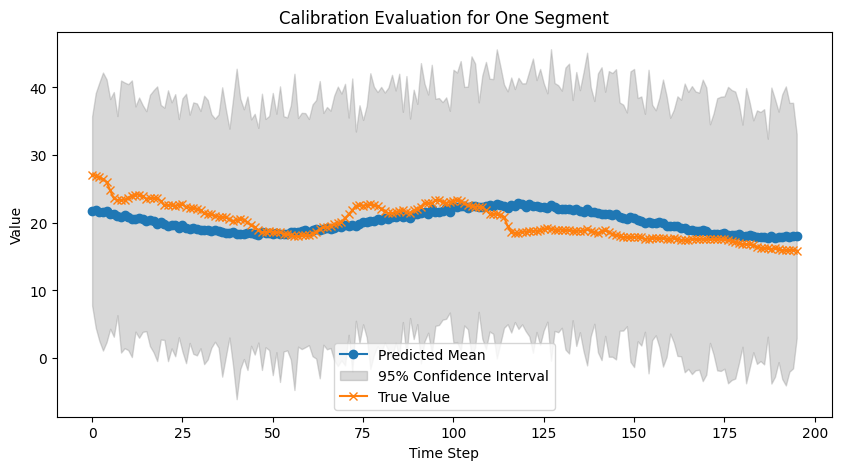

In [56]:
import math

def evaluate_calibration(pred_mean, pred_std, y_true, confidence=0.95):
    """
    주어진 예측 분포(평균, 표준편차)와 실제 관측값을 바탕으로, 
    nominal confidence level에 해당하는 신뢰구간 내에 실제값이 포함되는 비율(empirical coverage)을 계산한다.
    
    Args:
        pred_mean (torch.Tensor): 예측된 평균, shape: [1, horizon, num_features]
        pred_std (torch.Tensor): 예측된 표준편차, pred_mean과 동일한 shape
        y_true (torch.Tensor): 실제 관측값, pred_mean과 동일한 shape
        confidence (float): nominal confidence level, 기본값 0.95
        
    Returns:
        empirical_coverage (float): 신뢰구간 포함 비율 (0 ~ 1)
        lower_bound (torch.Tensor): 계산된 신뢰구간 하한
        upper_bound (torch.Tensor): 계산된 신뢰구간 상한
    """
    # ================================================================== #
    #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
    # ================================================================== #
    
    z = torch.erfinv(1 - (1 - torch.tensor(confidence)) / 2)
    lower_bound = pred_mean - pred_std * z
    upper_bound = pred_mean + pred_std * z
    
    within_interval = ((y_true >= lower_bound) & (y_true <= upper_bound)).int()
    empirical_coverage = within_interval.sum() / pred_mean.shape[1]
    
    # ================================================================== #
    #         END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)          #
    # ================================================================== #
    
    return empirical_coverage, lower_bound, upper_bound

# 모델 inference: 하나의 segment에 대해서만 평가
model.eval()
with torch.no_grad():
    sample_idx = 0
    # 하나의 테스트 샘플 선택: context와 대응되는 ground truth future
    x_context = X_test[sample_idx:sample_idx+1]    # shape: [1, window_size, num_features]
    y_true = y_test[sample_idx:sample_idx+1]         # shape: [1, horizon, num_features]
    
    x_context = x_context.to(device)
    y_true = y_true.to(device)
    
    # 모델 inference: 예측된 mean과 std 반환, 각각 [1, horizon, num_features]
    pred_mean, pred_std = model(x_context)
    
    # 캘리브레이션 평가
    empirical_coverage, lb, ub = evaluate_calibration(pred_mean, pred_std, y_true, confidence=0.95)
    print("Empirical Coverage: {:.2f}%".format(empirical_coverage * 100))
    
    # 첫 번째 샘플의 예측 결과 시각화 (squeeze하여 불필요한 차원 제거)
    horizon = y_true.shape[1]
    time_steps = range(horizon)
    
    plt.figure(figsize=(10, 5))
    plt.plot(time_steps, pred_mean.squeeze().cpu(), label='Predicted Mean', marker='o')
    plt.fill_between(time_steps, lb.squeeze().cpu(), ub.squeeze().cpu(), color='gray', alpha=0.3, label='95% Confidence Interval')
    plt.plot(time_steps, y_true.squeeze().cpu(), label='True Value', marker='x')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title('Calibration Evaluation for One Segment')
    plt.legend()
    plt.show()


### [답안 검증 6-4]
문제 없이 구현했다면, Empirical Coverage의 값이 100%로 출력되고, 아래와 같은 plot을 볼 수 있다.

![plot](./figs/sample_fig_6_3.png)

### [답안 제출 6-4] 수정 금지, 실행만 하시오.

In [ ]:
skada.Q6_4_answer(evaluate_calibration)

이 프로젝트에서는 미래 온도 변화를 예측하기 위한 시계열 예측 모델을 다루었다.

효율적인 모델 학습을 위해 patch 단위로 예측할 수 있는 PatchTST 구조를 구현하고, 학습된 모델을 기반으로 teacher forcing 및 model forcing 기법을 활용한 인퍼런스 과정을 살펴보았다.

마지막으로, 모델을 고도화하기 위해 uncertainty까지 함께 예측하는 방식을 탐구하였으며, 이를 위해 Gaussian log-likelihood loss를 적용해 모델을 학습하는 방법을 다루었다.

# 주관식 문제 종료
## 반드시 오른쪽 상단의 제출 버튼을 눌러 답안을 최종 제출하시오.